In [1]:
!pip install pingouin

import glob
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt


csv = glob.glob('/kaggle/input/**/open_llm_leaderboard_2026.csv', recursive=True)[0]
llm_evaluation = pd.read_csv(csv)
print(f"Lines loaded: {len(llm_evaluation)}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 9.2 MB/s eta 0:00:00
Lines loaded: 4576


# **1. Data validation and inspection**

First of all, I made the model names readable and displayed the top 20 based on the composite average of the six normalized benchmarks.


In [2]:
llm_evaluation["fullname_clean"] = (
    llm_evaluation["model"]
    .str.replace(r"<.*?>", "", regex=True)
    .str.replace("📑", "", regex=False)
    .str.strip()
)

llm_evaluation["model_name"] = (
    llm_evaluation["fullname_clean"]
    .str.split("/")
    .str[-1]
)

top_10 = llm_evaluation.sort_values("average", ascending=False).head(10)[['model_name', 'params_b', 'average']]
print(top_10)

                              model_name  params_b    average
0                 calme-3.2-instruct-78b    77.965  52.081384
1                 calme-3.1-instruct-78b    77.965  51.287490
2                 CalmeRys-78B-Orpo-v0.1    77.965  51.231323
3                      calme-2.4-rys-78b    77.965  50.765047
4       Qwen2.5-72B-Instruct-abliterated    72.706  48.106471
5                   Qwen2.5-72B-Instruct    72.706  47.980460
6                  calme-2.1-qwen2.5-72b    72.700  47.856722
7                 Homer-v1.0-Qwen2.5-72B    72.706  47.464376
8                    qwen2.5-test-32b-it    32.764  47.368357
9  Linkbricks-Horizon-AI-Avengers-V1-32B    32.760  47.336956


# **2. Does model quality depend on its size?**

**2.1 — Size Grouping**

Models vary a lot in size — from tiny 1–3B all the way to massive 70B+. To make a fair comparison, we split them into three groups: small (under 10B), medium (10–50B), and large (50B+).

In [3]:
# Grouping models into 3 size buckets based on parameter count
def size_bucket(x):
    if x < 10:
        return 'small (<10B)'
    elif x < 50:
        return 'medium (10-50B)'
    else:
        return 'large (50B+)'

llm_evaluation['size_group'] = llm_evaluation['params_b'].apply(size_bucket)
print(llm_evaluation['size_group'].value_counts())

size_group
small (<10B)       3154
medium (10-50B)    1245
large (50B+)        177
Name: count, dtype: int64


**2.2 — Checking the average score per group**

Here we check — do larger models actually score higher? And how consistent are they within each group — or do models of the same size behave very differently from one another?





In [4]:
# average score per group
print(llm_evaluation.groupby('size_group')['average'].mean())

# full stats — spread, min, max, etc.
print(llm_evaluation.groupby('size_group')['average'].describe())

size_group
large (50B+)       35.220803
medium (10-50B)    29.036601
small (<10B)       18.211846
Name: average, dtype: float64
                  count       mean        std       min        25%        50%  \
size_group                                                                      
large (50B+)      177.0  35.220803  10.189467  3.428827  30.236001  36.822864   
medium (10-50B)  1245.0  29.036601  10.441383  0.737851  21.240878  30.281489   
small (<10B)     3154.0  18.211846   8.765395  1.476339  10.292931  19.508674   

                       75%        max  
size_group                             
large (50B+)     43.002582  52.081384  
medium (10-50B)  38.226937  47.368357  
small (<10B)     24.219029  47.091545  


**2.3 — Visualizing the distribution with a boxplot**

A boxplot is like a "portrait" of each group. It shows not just the average score, but also how consistent models are within the group — and whether there are any outliers: models that behave very differently from the rest of their group.

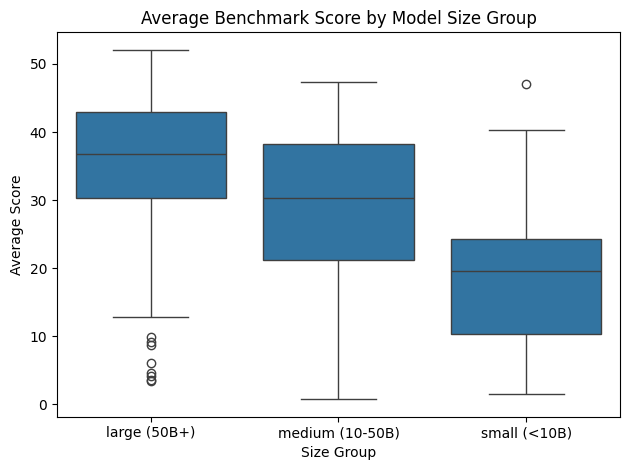

In [5]:
sns.boxplot(data=llm_evaluation, x='size_group', y='average')
plt.title('Average Benchmark Score by Model Size Group')
plt.xlabel('Size Group')
plt.ylabel('Average Score')
plt.tight_layout()
plt.show()

**2.4 — Is the difference actually meaningful?**

We can see a difference — but is it just random noise? The pairwise test checks: "if we picked a different sample of models, would the difference still hold?" Bonferroni correction is applied because we're comparing three pairs at once — without it, the chance of finding a "significant" result by accident goes up

In [6]:
import pingouin as pg
pairwise_tests_result = pg.pairwise_tests(
    data=llm_evaluation,
    dv="average",
    between="size_group",
    padjust="bonf"
)
print(pairwise_tests_result)

     Contrast                A                B  Paired  Parametric  \
0  size_group     large (50B+)  medium (10-50B)   False        True   
1  size_group     large (50B+)     small (<10B)   False        True   
2  size_group  medium (10-50B)     small (<10B)   False        True   

           T          dof alternative          p_unc         p_corr p_adjust  \
0   7.531906   231.740100   two-sided   1.110963e-12   3.332890e-12     bonf   
1  21.760916   190.903378   two-sided   1.358001e-53   4.074002e-53     bonf   
2  32.355475  1972.179461   two-sided  1.353846e-184  4.061537e-184     bonf   

         BF10    hedges  
0   6.432e+10  0.593722  
1   1.947e+94  1.922259  
2  1.034e+202  1.167475  


**Key Takeaways**

Bigger models score higher — but the gains are not equal at every step:

- **Large vs Small** → +1.92 🔴 Huge difference
- **Medium vs Small** → +1.17 🟠 Noticeable difference  
- **Large vs Medium** → +0.59 🟡 Still there, but smaller

In other words: the biggest jump in quality happens when you go from **small to medium** models. Going from **medium to large** still helps — but the gain is roughly twice as small. This is a classic case of **diminishing returns from scale**.

# **3. Is bigger always better? Efficiency vs. Performance**

We already know that larger models score higher. But here's the real question: how much performance do you actually get per billion parameters? This is efficiency. A model can have a great score — but if it took 70 billion parameters to get there, was it really worth it?

In [7]:
parametrs_comparing_group = llm_evaluation.copy()

parametrs_comparing_group["efficiency"] = np.where(
    parametrs_comparing_group["params_b"] > 0,
    parametrs_comparing_group["average"] / parametrs_comparing_group["params_b"],
    np.nan
)

summary = parametrs_comparing_group.groupby("size_group").agg({
    "average": "mean",
    "efficiency": "mean",
    "params_b": "mean",
    "co2_cost_kg": "mean"
}).reset_index()

print(summary)

        size_group    average  efficiency   params_b  co2_cost_kg
0     large (50B+)  35.220803    0.480334  74.896921    40.938474
1  medium (10-50B)  29.036601    1.983847  16.348686     4.762888
2     small (<10B)  18.211846    6.915373   5.646831     1.581859


Performance grows with size — but efficiency drops dramatically:

- **Small models** → avg score 18.2, efficiency 6.9 — cheapest, but weakest
- **Medium models** → avg score 29.0, efficiency 1.98 — solid performance, reasonable cost
- **Large models** → avg score 35.2, efficiency 0.48 — best scores, but CO₂ cost is ~25x higher than small models

The gap tells the real story: large models score **2x better** than small ones, 
but consume **25x more CO₂** (40.9 kg vs 1.6 kg).

Medium models hit the sweet spot — you get a **+10 point score boost** 
over small models while keeping CO₂ costs relatively low (4.8 kg).

**Bottom line:** if raw performance is the priority — go large. 
If you care about cost and environmental impact — **medium is the smarter choice**.

# **4. Do merged models actually perform better?**

Merged models are created by combining weights from two or more models into one. The idea sounds promising — take the best of multiple models and blend them together. But does it actually work in practice? Let's check.

In [8]:
merge_summary = parametrs_comparing_group.groupby(['size_group', 'merged'])['average'].agg(['mean', 'count']).reset_index()
print(merge_summary)

        size_group  merged       mean  count
0     large (50B+)   False  35.016505    153
1     large (50B+)    True  36.523207     24
2  medium (10-50B)   False  28.716398    965
3  medium (10-50B)    True  30.140159    280
4     small (<10B)   False  17.624253   2743
5     small (<10B)    True  22.133422    411


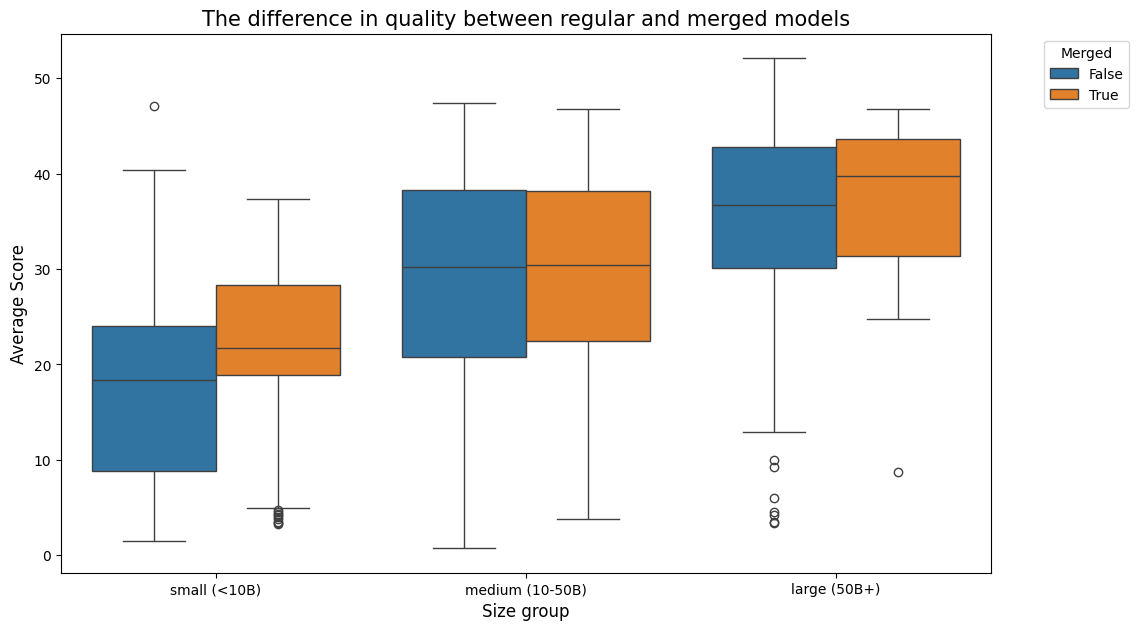

In [9]:
plt.figure(figsize = (12, 7))

ax = sns.boxplot(data = parametrs_comparing_group, 
                 x = 'size_group', 
                 y = 'average', 
                 hue = 'merged', 
                 order = ['small (<10B)', 'medium (10-50B)', 'large (50B+)'])

plt.title('The difference in quality between regular and merged models', fontsize=15)
plt.xlabel('Size group', fontsize=12)
plt.ylabel('Average Score', fontsize=12)
plt.legend(title='Merged', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

In [10]:
# Top 3 models for each size group and merge type
top_detailed = llm_evaluation.sort_values('average', ascending=False).groupby(['size_group', 'merged']).head(3)
top_detailed = top_detailed.set_index(['size_group', 'merged', 'model_name'])[['average']]
top_detailed = top_detailed.sort_index(level=[0, 1], ascending=[False, False])
print(top_detailed)

                                                                             average
size_group      merged model_name                                                   
small (<10B)    True   Qwen2.5-Dyanka-7B-Preview                           37.295944
                       qwen2.5-7b-cabs-v0.3                                36.935047
                       qwen2.5-7b-cabs-v0.4                                36.881946
                False  T3Q-Qwen2.5-14B-Instruct-1M-e3                      47.091545
                       Chocolatine-Fusion-14B                              40.361559
                       phi-4-unsloth-bnb-4bit                              39.216451
medium (10-50B) True   zetasepic-abliteratedV2-Qwen2.5-32B-Inst-BaseMe...  46.763621
                       huihui-ai-abliterated-Qwen2.5-32B-Inst-BaseMerg...  45.657847
                       ultiima-32B                                         45.403218
                False  qwen2.5-test-32b-it                       

The effect of merging varies a lot depending on model size:

- **Small models** → merging clearly helps — merged models score noticeably higher
- **Medium models** → merging doesn't help — performance stays the same or slightly drops
- **Large models** → merging slightly improves the average, but flattens the distribution: 
  the worst results disappear, but so do the best ones

**Bottom line:** merging is not a universal recipe for improvement. 
It works well as a boost for small models, but for large models 
it trades peak performance for consistency. 
For medium models — it's probably not worth the effort.

# **5. Popularity vs. Quality**

More likes = better model? Let's check. First, we look at how likes are actually distributed across all models.



In [11]:
print(parametrs_comparing_group['hub_likes'].quantile([0.5, 0.75, 0.9, 0.95, 0.99]))

0.50       1.00
0.75       5.00
0.90      53.00
0.95     172.00
0.99    1177.25
Name: hub_likes, dtype: float64


In [12]:
print(f"models with 0 likes: {(parametrs_comparing_group['hub_likes'] == 0).sum()}")
print(f"models with >10 likes: {(parametrs_comparing_group['hub_likes'] > 10).sum()}")
print(f"models with >100 likes: {(parametrs_comparing_group['hub_likes'] > 100).sum()}")

models with 0 likes: 2008
models with >10 likes: 873
models with >100 likes: 334


More of all models have 0 or up to 10 likes. This means "popularity" here is basically binary — a model is either noticed by people or it isn't. There's no real popularity gradient for the majority of models. So we filter to only models with more than 10 likes — ones that were actually noticed.

In [13]:
# keeping only models that got real attention
df_pop = parametrs_comparing_group[parametrs_comparing_group['hub_likes'] > 10].copy()
print(f"working with {len(df_pop)} models")

working with 873 models


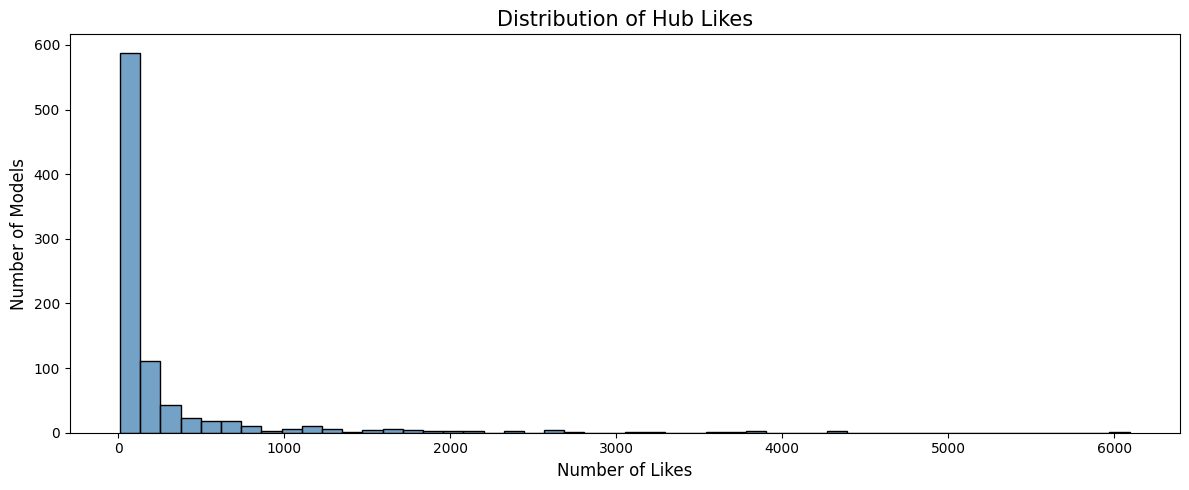

In [14]:
plt.figure(figsize=(12, 5))

sns.histplot(
    df_pop['hub_likes'], 
    bins=50, 
    color='steelblue'
)

plt.title('Distribution of Hub Likes', fontsize=15)
plt.xlabel('Number of Likes', fontsize=12)
plt.ylabel('Number of Models', fontsize=12)


plt.tight_layout()
plt.show()

Since the distribution of likes is highly skewed (most models have up to 100 likes, and then there are models with a huge number of likes, but there are much fewer of them), we use Spearman correlation

In [15]:
from scipy import stats

df_pop['hub_likes'] = np.log10(df_pop['hub_likes'])

slope, intercept, r, p, _ = stats.linregress(df_pop['hub_likes'], df_pop['average'])

print(f"Spearman correlation: {stats.spearmanr(df_pop['hub_likes'], df_pop['average']).statistic:.3f}")
print(f"p-value: {stats.spearmanr(df_pop['hub_likes'], df_pop['average']).pvalue:.4f}")
print(f"R² linear regression: {r**2:.3f}")

Spearman correlation: -0.144
p-value: 0.0000
R² linear regression: 0.018


In [16]:
top_detailed = llm_evaluation.sort_values('average', ascending=False).groupby(['size_group', 'merged']).head(3)
top_detailed = top_detailed.set_index(['size_group', 'merged', 'model_name', 'architecture'])[['average', 'hub_likes']]
top_detailed = top_detailed.sort_index(level=[0, 1], ascending=[False, False])
print(top_detailed)

                                                                                              average  \
size_group      merged model_name                                         architecture                  
small (<10B)    True   Qwen2.5-Dyanka-7B-Preview                          Qwen2ForCausalLM  37.295944   
                       qwen2.5-7b-cabs-v0.3                               Qwen2ForCausalLM  36.935047   
                       qwen2.5-7b-cabs-v0.4                               Qwen2ForCausalLM  36.881946   
                False  T3Q-Qwen2.5-14B-Instruct-1M-e3                     Unknown           47.091545   
                       Chocolatine-Fusion-14B                             Qwen2ForCausalLM  40.361559   
                       phi-4-unsloth-bnb-4bit                             LlamaForCausalLM  39.216451   
medium (10-50B) True   zetasepic-abliteratedV2-Qwen2.5-32B-Inst-BaseMe... Qwen2ForCausalLM  46.763621   
                       huihui-ai-abliterated-Qwen2.5-32

Popularity and quality are barely related — and what little relationship exists goes in the wrong direction:

- **Spearman correlation: -0.144** → more popular models are actually slightly *worse*
- **p-value = 0.0000** → this is not random noise, the pattern is real
- **R² = 0.018** → likes explain only 2% of the difference in model quality

In other words: 98% of what makes one model better than another 
has nothing to do with how many likes it has.

The top-performing models often fly under the radar — 
high quality does not guarantee popularity on the Hub.


# **6. Architecture vs. Performance**



In [17]:
# How many models use each architecture?
print(parametrs_comparing_group['architecture'].value_counts().head(10))

architecture
LlamaForCausalLM      1849
Qwen2ForCausalLM      1308
MistralForCausalLM     615
Gemma2ForCausalLM      248
MixtralForCausalLM      80
Qwen2Model              73
Phi3ForCausalLM         67
?                       49
GemmaForCausalLM        30
PhiForCausalLM          30
Name: count, dtype: int64


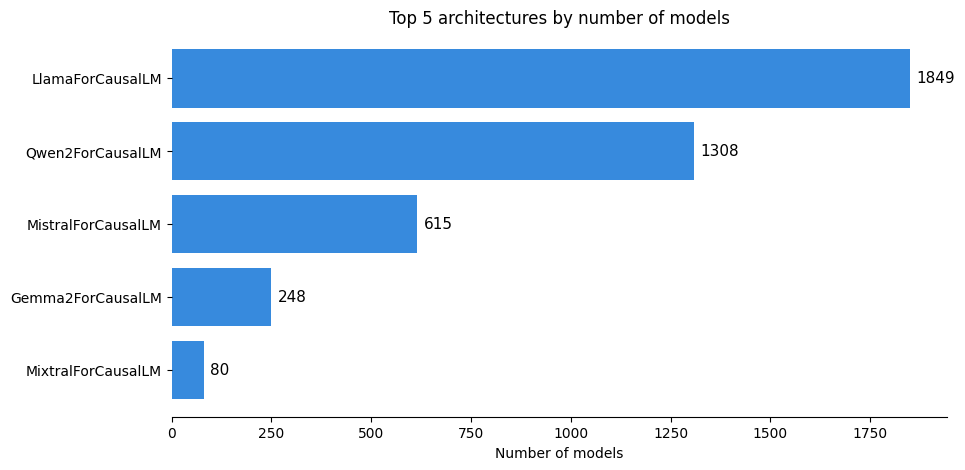

In [18]:
arch_counts = parametrs_comparing_group['architecture'].value_counts().head(5)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(arch_counts.index[::-1], arch_counts.values[::-1], color='#378ADD')
ax.bar_label(bars, padding=5, fontsize=11)
ax.set_xlabel('Number of models')
ax.set_title('Top 5 architectures by number of models')
ax.spines[['top', 'right', 'left']].set_visible(False)
plt.show()

In [19]:
# Filtering to top 4 architectures and comparing scores by size group
top_architecture = ['LlamaForCausalLM', 'Qwen2ForCausalLM', 'MistralForCausalLM', 'Gemma2ForCausalLM']

arch = parametrs_comparing_group[parametrs_comparing_group['architecture'].isin(top_architecture)].copy()

arch['arch'] = arch['architecture'].map({
    'LlamaForCausalLM': 'Llama',
    'Qwen2ForCausalLM': 'Qwen2',
    'MistralForCausalLM': 'Mistral',
    'Gemma2ForCausalLM': 'Gemma2'
})

arch_grop_size = arch.groupby(['arch', 'size_group'])['average'].agg(['mean', 'median', 'count']).round(2)
print(arch_grop_size)

                          mean  median  count
arch    size_group                           
Gemma2  medium (10-50B)  29.47   33.78    147
        small (<10B)     21.40   21.29    101
Llama   large (50B+)     33.28   35.89    105
        medium (10-50B)  27.65   29.04    251
        small (<10B)     19.48   21.67   1493
Mistral large (50B+)     46.52   46.52      1
        medium (10-50B)  23.11   23.01    258
        small (<10B)     18.05   19.53    356
Qwen2   large (50B+)     41.22   44.07     54
        medium (10-50B)  36.69   38.87    420
        small (<10B)     18.29   16.53    834


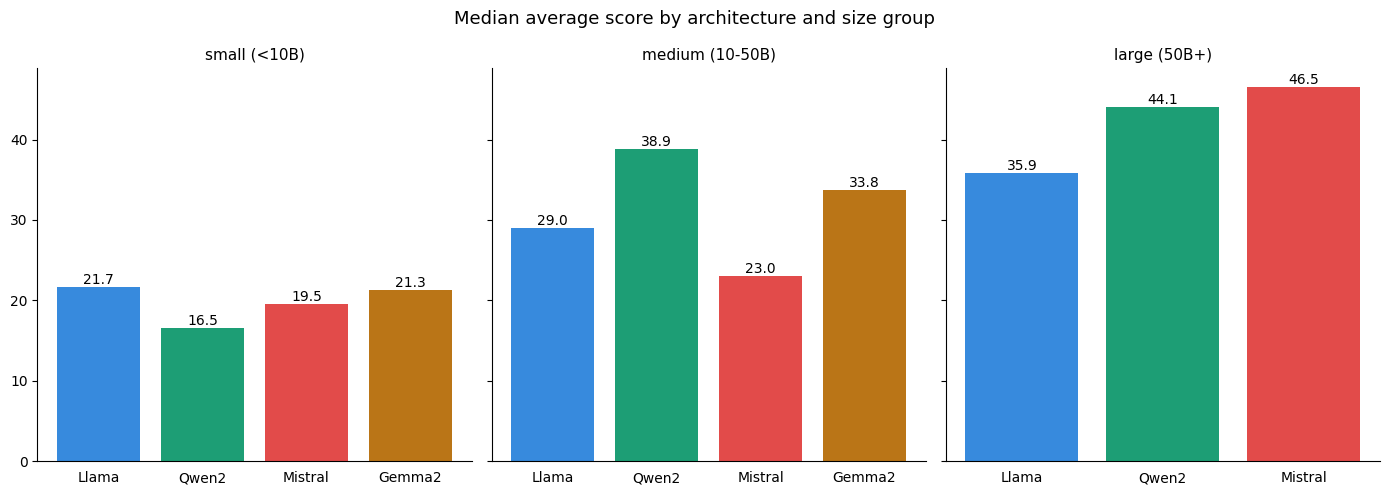

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

size_groups = ['small (<10B)', 'medium (10-50B)', 'large (50B+)']
architecture = ['Llama', 'Qwen2', 'Mistral', 'Gemma2']
colors = {'Llama': '#378ADD', 'Qwen2': '#1D9E75', 'Mistral': '#E24B4A', 'Gemma2': '#BA7517'}

for ax, size in zip(axes, size_groups):
    data = arch[arch['size_group'] == size].groupby('arch')['average'].median()
    data = data.reindex(architecture).dropna()
    bars = ax.bar(data.index, data.values, color=[colors[a] for a in data.index])
    ax.bar_label(bars, fmt='%.1f')
    ax.set_title(size, fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(bottom=False)

fig.suptitle('Median average score by architecture and size group', fontsize=13)
plt.tight_layout()
plt.show()

Architecture matters — but only once models get big enough:

- **Small (<10B)** → architecture barely matters, all four perform similarly
- **Medium (10–50B)** → Qwen2 pulls ahead clearly
- **Large (50B+)** → Mistral leads (46.5), but there's only 1 model in 
  this group — not a reliable result. Qwen2 is the safe bet here (44.1)


# **7. Benchmark Breakdown by Architecture**

Overall scores are useful, but they hide a lot. Let's go deeper and look at how each architecture performs across all 6 benchmarks individually — because a model that's great at math might struggle with logic, and vice versa.

In [21]:
benchmarks = ['ifeval', 'bbh', 'math_lvl_5', 'gpqa', 'musr', 'mmlu_pro']

bench_arch = arch.groupby('arch')[benchmarks].max().round(1)
print(bench_arch)

         ifeval   bbh  math_lvl_5  gpqa  musr  mmlu_pro
arch                                                   
Gemma2     81.5  51.1        28.2  18.0  21.8      41.7
Llama      90.0  76.7        56.1  29.4  25.9      59.3
Mistral    84.0  52.8        49.5  24.9  32.4      57.3
Qwen2      86.6  65.5        71.5  22.3  38.7      70.0


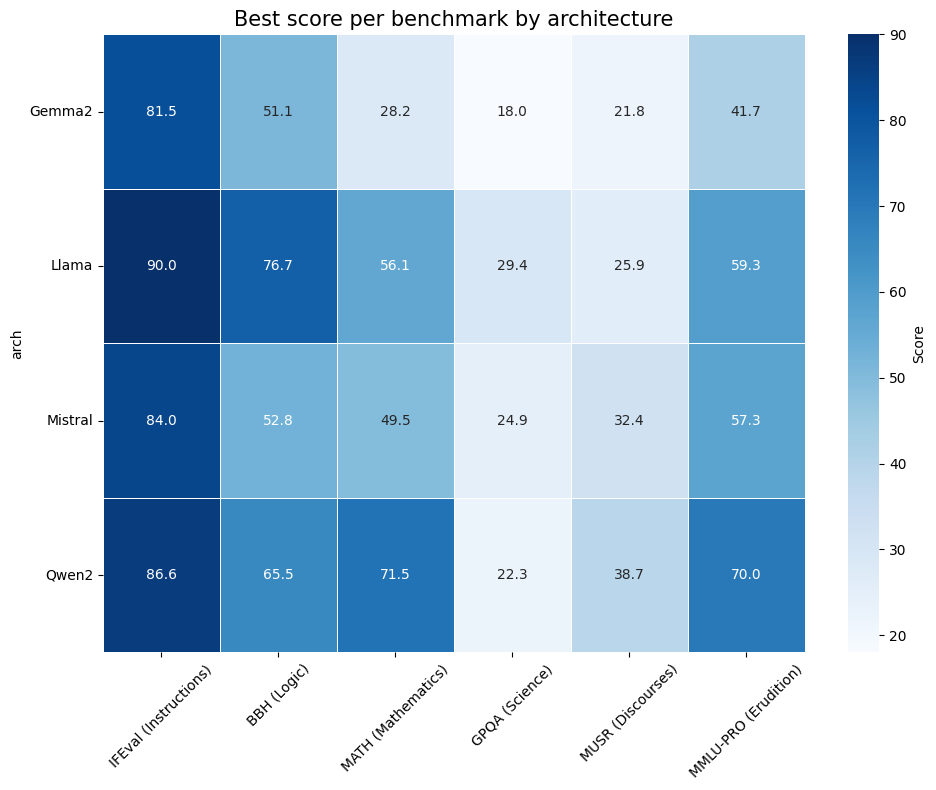

In [22]:
labels = [
    'IFEval (Instructions)', 
    'BBH (Logic)', 
    'MATH (Mathematics)', 
    'GPQA (Science)', 
    'MUSR (Discourses)', 
    'MMLU-PRO (Erudition)'
]
index = ['Gemma2', 'Llama', 'Mistral', 'Qwen2']

plt.figure(figsize=(10, 8))

sns.heatmap(bench_arch, annot=True, cmap='Blues', fmt=".1f", linewidths=0.5,
            cbar_kws={"label": "Score"},
            xticklabels=labels,
            yticklabels=index)

plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.title('Best score per benchmark by architecture', fontsize=15)
plt.tight_layout()
plt.show()

Different architectures have different strengths — there's no single winner:

- **Llama** → champion in logic (BBH: 76.7) and instruction following (IFEval: 90.0)
- **Qwen2** → champion in math (MATH: 71.5) and general knowledge (MMLU-PRO: 70.0)


# 8. Does having a chat template make models better?**

Some models are trained specifically for conversations — they have a chat template, which tells the model how to handle instructions and dialogue. The hypothesis is simple: models with a chat template should be better at following instructions. Let's check if that's actually true.

In [23]:
# Comparing average benchmark scores for models with and without chat template
comparison = parametrs_comparing_group.groupby('chat_template')[benchmarks].agg(['mean', 'median']).round(2)
print(comparison)

              ifeval           bbh        math_lvl_5         gpqa         \
                mean median   mean median       mean median  mean median   
chat_template                                                              
False          36.48  37.44  27.36  29.82      13.73   9.33  7.41   6.60   
True           53.83  56.16  27.91  29.17      17.20  12.69  6.09   5.15   

                musr        mmlu_pro         
                mean median     mean median  
chat_template                                
False          11.34  11.21    25.07  26.03  
True            8.76   8.93    25.71  27.85  


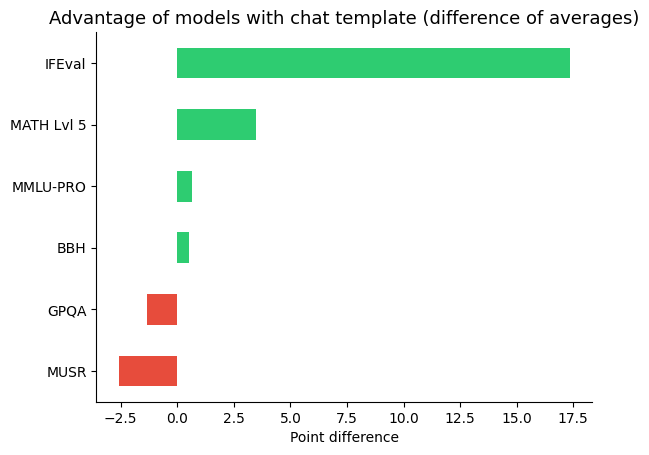

In [24]:
labels_dict = {
    'ifeval':     'IFEval',
    'bbh':        'BBH',
    'math_lvl_5': 'MATH Lvl 5',
    'gpqa':       'GPQA',
    'musr':       'MUSR',
    'mmlu_pro':   'MMLU-PRO'
}

diff = (parametrs_comparing_group[parametrs_comparing_group['chat_template'] == True][benchmarks].mean() - 
        parametrs_comparing_group[parametrs_comparing_group['chat_template'] == False][benchmarks].mean()).round(2).rename(labels_dict).sort_values()

colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in diff.sort_values()]
ax = diff.sort_values().plot(kind='barh', color=colors)
ax.spines[['top', 'right']].set_visible(False)

plt.title('Advantage of models with chat template (difference of averages)', fontsize=13)
plt.xlabel('Point difference')
plt.show()

Green bars = chat template helps. Red bars = chat template actually hurts.

In [25]:
# Breaking it down by architecture, size group and chat template
arch_grop_size = arch.groupby(['arch', 'size_group', 'chat_template'])['average'].agg(['mean', 'median', 'count']).round(2)
print(arch_grop_size)

                                        mean  median  count
arch    size_group      chat_template                      
Gemma2  medium (10-50B) False          26.45   31.79     42
                        True           30.68   34.11    105
        small (<10B)    False          23.77   23.70     44
                        True           19.58   19.13     57
Llama   large (50B+)    False          30.25   32.00     35
                        True           34.79   36.53     70
        medium (10-50B) False          21.27   22.00    102
                        True           32.01   35.59    149
        small (<10B)    False          17.33   20.41    684
                        True           21.30   23.18    809
Mistral large (50B+)    True           46.52   46.52      1
        medium (10-50B) False          22.35   22.28    129
                        True           23.87   24.97    129
        small (<10B)    False          17.74   19.84    209
                        True           1

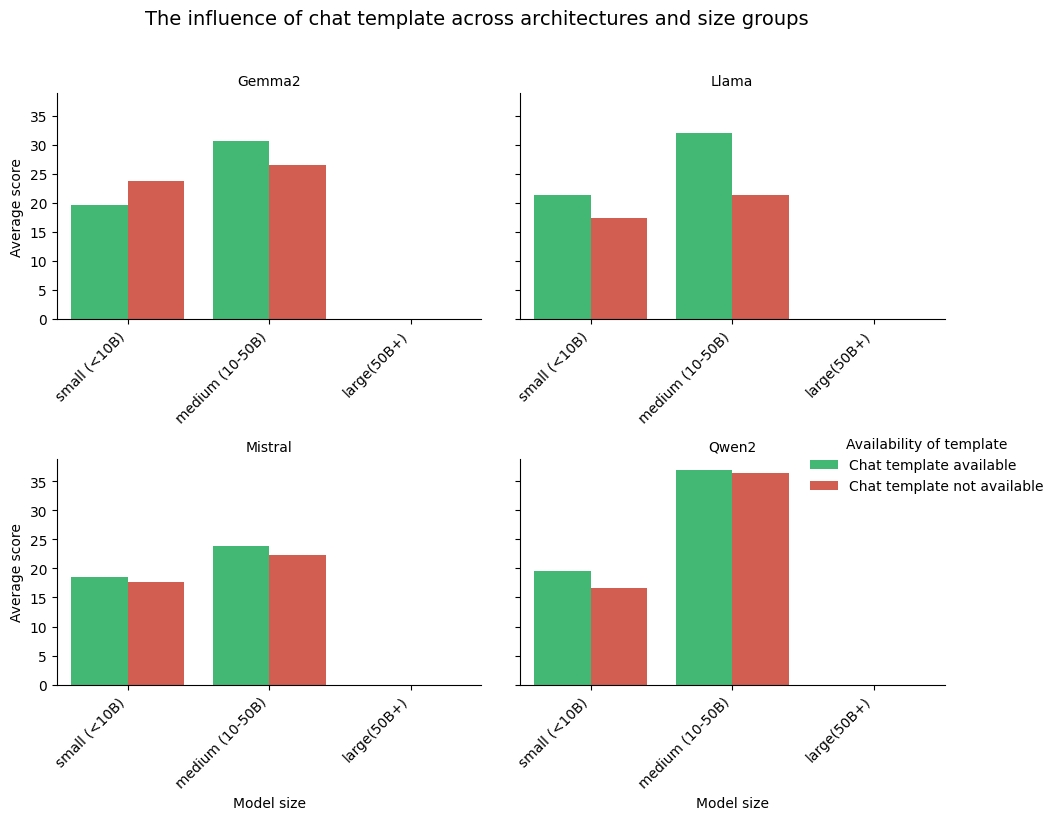

In [26]:
# Visualizing the effect across architectures
plot_df = arch_grop_size.reset_index()
plot_df['chat_template'] = plot_df['chat_template'].map({
    True: 'Chat template available',
    False: 'Chat template not available'
})

size_order = ['small (<10B)', 'medium (10-50B)', 'large(50B+)']
hue_order = ['Chat template available', 'Chat template not available']

ax = sns.catplot(
    data=plot_df,
    kind='bar',
    x='size_group',
    y='mean',
    hue='chat_template',
    col='arch',
    order=size_order,
    hue_order=hue_order,
    palette={'Chat template available': '#2ecc71', 'Chat template not available': '#e74c3c'},
    height=4, aspect=0.9,
    col_wrap=2
)

ax.set_titles('{col_name}')
ax.set_axis_labels('Model size', 'Average score')


for axis in ax.axes.flat:
    axis.tick_params(labelbottom=True)
    plt.setp(axis.get_xticklabels(), rotation=45, ha='right')

ax.fig.suptitle('The influence of chat template across architectures and size groups', 
               fontsize=14, y=1.02)
sns.move_legend(ax, loc='upper right', bbox_to_anchor=(1.1, 0.5), title='Availability of template')
plt.tight_layout()
plt.show()

The hypothesis is confirmed — but with an interesting twist:

- **IFEval** → biggest winner: +17 points for chat template models. 
  Makes sense — this benchmark literally tests instruction following
- **GPQA and MUSR** → chat template actually hurts here. 
  These benchmarks require deep reasoning, not conversation skills
- **Across architectures** → in 9 out of 10 groups, chat models outperform base models
- **One exception:** small Gemma2 models — here the base model is 
  actually stronger than its chat versions